### **`GROUP 4 PROJECT`**
***
## Group Members
----
1. Abdullahi Hassan
2. Lauren Kuria
3. Yvonne Rajula 
4. Dahir Mohamed
5. Samantha jepkosgei
6. Claire njeri
---

# Phase 4 Final: Advanced Sentiment Analysis for Apple & Google
---

## 1. Business Understanding
---
### Project Overview
This project focuses on building an advanced **Natural Language Processing (NLP)** sentiment classifier for major tech brands. Using a dataset of tweets collected during the **SXSW (South by Southwest)** conference, we aim to automate the process of understanding public sentiment toward Apple and Google products.

---

### The Stakeholder
The primary stakeholders are the **Customer Success and Branding Teams** at **Apple** and **Google**. These departments are responsible for:
* Monitoring brand reputation in real-time.
* Identifying product bugs or service outages reported by users.
* Engaging with the community to mitigate public relations crises.
---
### The Business Problem
High-profile events like SXSW generate a massive volume of social media activity. For stakeholders, this presents several challenges:
1. **Scalability:** The sheer volume of tweets (thousands per hour) makes manual human moderation impossible.
2. **Noise vs. Signal:** Most tweets are neutral or "no emotion." However, **negative sentiment** often signals critical issues like app crashes ("crashy"), hardware failures ("dead battery"), or poor customer service.
3. **Reaction Time:** In the age of viral social media, a delay of even a few hours in addressing a widespread complaint can lead to significant brand damage.

----

### Objective
The goal is to develop a multiclass sentiment classifier that can:
* **Automatically categorize** tweets into Positive, Negative, or Neutral sentiment.
* **Prioritize Negative Feedback:** The model must achieve high **Recall** for the "Negative Emotion" class to ensure the Branding Team never misses a critical customer complaint.
* **Inform Strategy:** By analyzing the most predictive words (features), we provide stakeholders with actionable data on *why* customers are dissatisfied.

----

### Success Criteria
Success is defined by the model's ability to accurately distinguish negative sentiment from the majority (neutral) class. We will evaluate performance using the **RECALL OF 0.80** and a **Confusion Matrix**, specifically monitoring for low False Negatives in the negative sentiment category.
***

## Introduction

The goal of this project is to build a Natural Language Processing (NLP) model that classifies text into three sentiment categories:

- Negative emotion  
- Positive emotion  
- No emotion toward brand or product  

This is a **multi-class classification problem** with imbalanced data, where some classes appear more frequently than others.

To solve this, we apply:
- Text preprocessing
- TF-IDF vectorization
- Multiple machine learning models
- Model evaluation and comparison
- Threshold tuning to maximize recall for the minority negative class
***

In [1]:
# ===================== IMPORT LIBRARIES =====================
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, f1_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Data Understanding

In [2]:
df = pd.read_csv('judge_1377884607_tweet_product_company.csv', encoding='latin1')

df = df.rename(columns={
    "tweet_text": "text",
    "emotion_in_tweet_is_directed_at": "product",
    "is_there_an_emotion_directed_at_a_brand_or_product": "sentiment"
})

print("Dataset Shape:", df.shape)
print("\nClass Distribution:")
print(df['sentiment'].value_counts(normalize=True))

Dataset Shape: (8721, 3)

Class Distribution:
sentiment
No emotion toward brand or product    0.591217
Positive emotion                      0.328976
Negative emotion                      0.062493
I can't tell                          0.017315
Name: proportion, dtype: float64


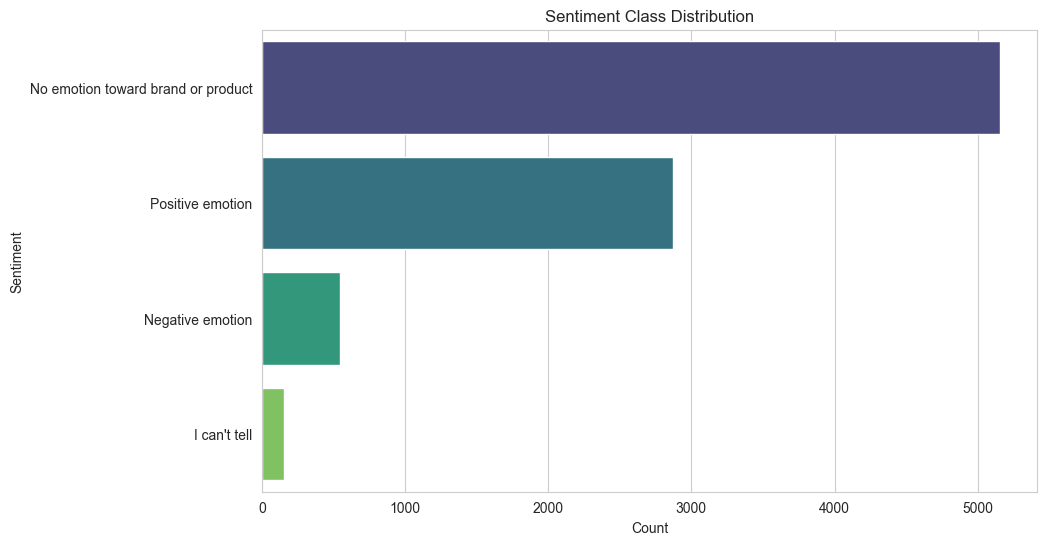

In [3]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, y='sentiment', order=df['sentiment'].value_counts().index, palette='viridis')
plt.title('Sentiment Class Distribution')
plt.xlabel('Count')
plt.ylabel('Sentiment')
plt.show()

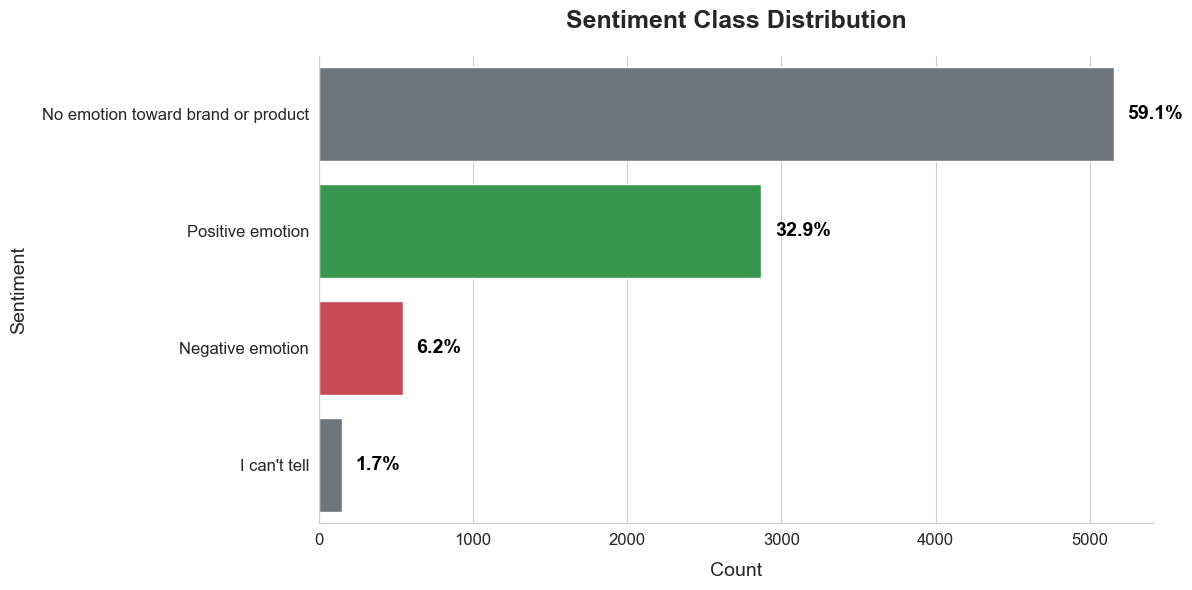

In [4]:

# Set style for cleaner look
sns.set_style("whitegrid")

# Larger figure size for slide visibility
plt.figure(figsize=(12, 6))

# Create horizontal bar plot (easier to read category names)
ax = sns.countplot(
    data=df,
    y='sentiment',  # horizontal bars
    order=df['sentiment'].value_counts().index,
    palette=['#6c757d', '#28a745', '#dc3545']  # gray, green, red
)

total = len(df)

# Add percentage labels with larger, bold text
for p in ax.patches:
    width = p.get_width()
    percentage = 100 * width / total
    
    ax.text(
        width + (total * 0.01),           # slight offset to the right
        p.get_y() + p.get_height() / 2,
        f'{percentage:.1f}%',
        va='center',
        fontsize=14,
        fontweight='bold',
        color='black'
    )

# Title and labels with larger fonts
plt.title('Sentiment Class Distribution', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Count', fontsize=14, labelpad=10)
plt.ylabel('Sentiment', fontsize=14, labelpad=10)

# Increase tick label size
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Remove top and right spines for cleaner look
sns.despine()

# Save at high DPI for PowerPoint (300 DPI ensures crispness)
plt.tight_layout()
plt.savefig('sentiment_distribution.png', dpi=300, bbox_inches='tight')
plt.show()